# Notebook 3: Preprocessing & Transforms

**Goal:** Visualize each preprocessing step — see exactly what happens to the data before it enters the model.

## Pipeline steps:
1. Load NIfTI → raw array
2. Reorient to RAS
3. Resample to uniform spacing [1.0, 0.5, 0.5] mm
4. Normalize intensity (nonzero z-score)
5. Random patch cropping (training only)
6. Augmentations: flip, rotate, noise

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path("..")

DATA_ROOT = PROJECT_ROOT / "data" / "spine-generic"
LABELS_ROOT = DATA_ROOT / "derivatives" / "labels"

# MONAI imports
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    Spacingd, NormalizeIntensityd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandGaussianNoised,
)
from cns_segmentation.models.segresnet import get_device

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {get_device()}")

In [2]:
# Find a subject with real data
def find_real_pair(data_root, labels_root):
    for sub_dir in sorted(data_root.iterdir()):
        if not sub_dir.is_dir() or not sub_dir.name.startswith("sub-"):
            continue
        sub_id = sub_dir.name
        img = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
        lbl = labels_root / sub_id / "anat" / f"{sub_id}_T2w_label-SC_seg.nii.gz"
        if img.exists() and img.stat().st_size > 1000:
            has_lbl = lbl.exists() and lbl.stat().st_size > 1000
            return {"image": str(img), "label": str(lbl) if has_lbl else str(img)}
    return None

sample = find_real_pair(DATA_ROOT, LABELS_ROOT)
print(f"Image: {sample['image']}")
print(f"Label: {sample['label']}")

Image: ../data/spine-generic/sub-amu01/anat/sub-amu01_T2w.nii.gz
Label: ../data/spine-generic/derivatives/labels/sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz


## Step 1: Load NIfTI

`LoadImaged` reads NIfTI files into MONAI MetaTensors (arrays with metadata).

After LoadImaged + EnsureChannelFirst:
  Image shape: torch.Size([1, 64, 320, 320])  (C, X, Y, Z)
  Image dtype: torch.float32
  Affine (from metadata):
  tensor([[  -0.8000,    0.0000,    0.0000,   19.1467],
        [   0.0000,    0.8000,    0.0000, -114.5590],
        [   0.0000,    0.0000,    0.8000, -105.6131]], dtype=torch.float64)
  Intensity range: [0.0, 2234.0]


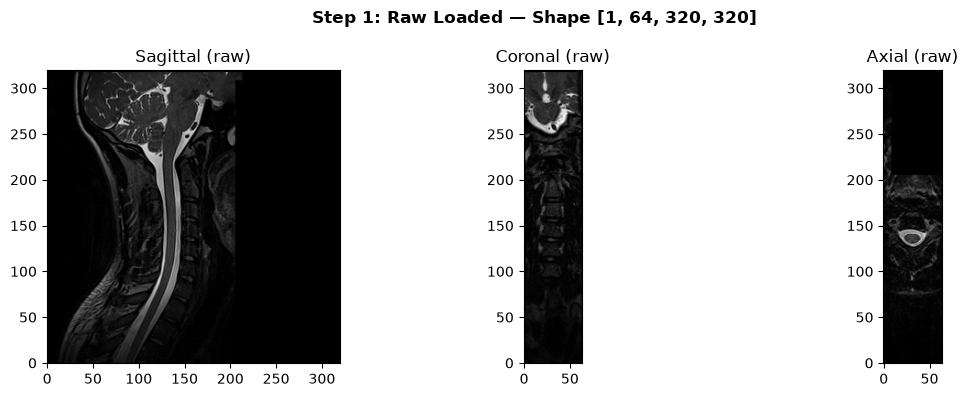

In [3]:
# Step 1: Load
step1 = Compose([LoadImaged(keys=["image", "label"]), EnsureChannelFirstd(keys=["image", "label"])])
data_loaded = step1(sample.copy())

img = data_loaded['image']
print(f"After LoadImaged + EnsureChannelFirst:")
print(f"  Image shape: {img.shape}  (C, X, Y, Z)")
print(f"  Image dtype: {img.dtype}")
print(f"  Affine (from metadata):")
print(f"  {img.meta['affine'][:3,:]}")
print(f"  Intensity range: [{img.min():.1f}, {img.max():.1f}]")

# Visualize raw
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
mid = [s//2 for s in img.shape[1:]]
axes[0].imshow(img[0, mid[0], :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Sagittal (raw)')
axes[1].imshow(img[0, :, mid[1], :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (raw)')
axes[2].imshow(img[0, :, :, mid[2]].T, cmap='gray', origin='lower')
axes[2].set_title(f'Axial (raw)')
plt.suptitle(f'Step 1: Raw Loaded — Shape {list(img.shape)}', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: Reorient to RAS

Different scanners save data in different orientations (LPS, RAS, etc.).  
We standardize to **RAS** (Right-Anterior-Superior) so all volumes are consistent.

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


After Orientationd(RAS):
  Shape: [1, 64, 320, 320]
  Shape changed: [1, 64, 320, 320] → [1, 64, 320, 320]


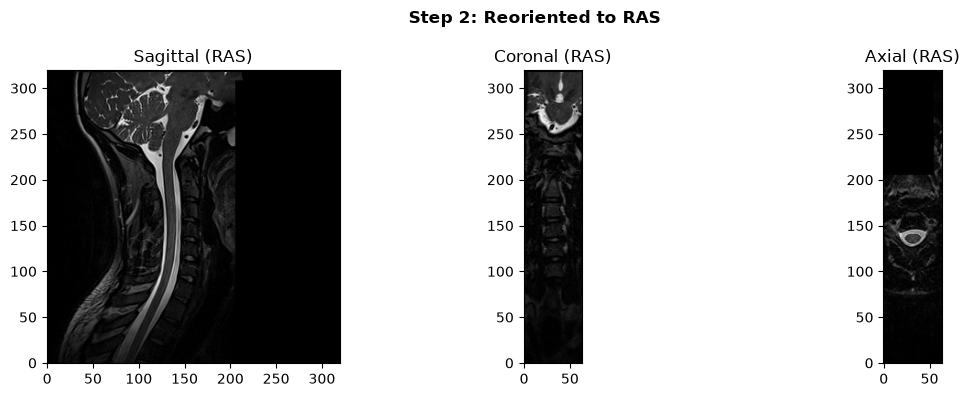

In [4]:
step2 = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
])
data_oriented = step2(sample.copy())

img2 = data_oriented['image']
print(f"After Orientationd(RAS):")
print(f"  Shape: {list(img2.shape)}")
print(f"  Shape changed: {list(img.shape)} → {list(img2.shape)}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
mid = [s//2 for s in img2.shape[1:]]
axes[0].imshow(img2[0, mid[0], :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Sagittal (RAS)')
axes[1].imshow(img2[0, :, mid[1], :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (RAS)')
axes[2].imshow(img2[0, :, :, mid[2]].T, cmap='gray', origin='lower')
axes[2].set_title(f'Axial (RAS)')
plt.suptitle('Step 2: Reoriented to RAS', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Resample to Uniform Spacing

Target: **[1.0, 0.5, 0.5] mm** (Z, Y, X).  
- 1.0mm slice thickness along the cord axis
- 0.5mm in-plane for good cross-sectional detail
- Bilinear for images, nearest-neighbor for labels

After Spacingd([1.0, 0.5, 0.5]):
  Shape: [1, 64, 320, 320] → [1, 51, 511, 511]
  Size change: 6553600 → 13317171 voxels


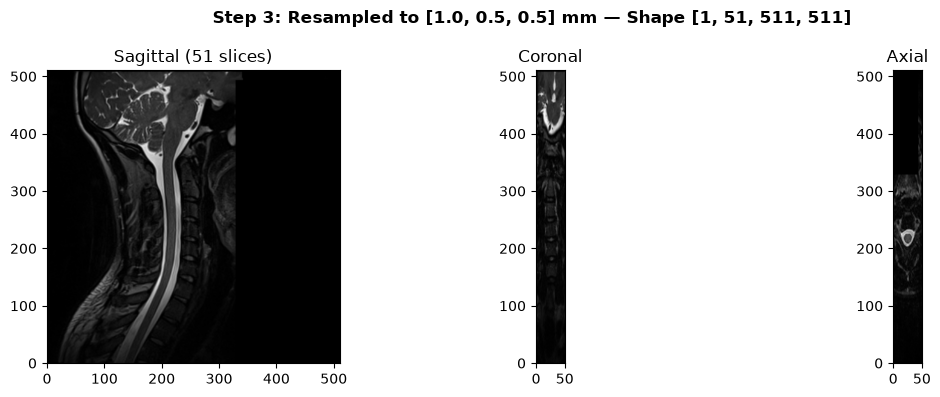

In [5]:
TARGET_SPACING = [1.0, 0.5, 0.5]

step3 = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
])
data_spaced = step3(sample.copy())

img3 = data_spaced['image']
print(f"After Spacingd({TARGET_SPACING}):")
print(f"  Shape: {list(img2.shape)} → {list(img3.shape)}")
print(f"  Size change: {np.prod(img2.shape[1:])} → {np.prod(img3.shape[1:])} voxels")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
mid = [s//2 for s in img3.shape[1:]]
axes[0].imshow(img3[0, mid[0], :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Sagittal ({img3.shape[1]} slices)')
axes[1].imshow(img3[0, :, mid[1], :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal')
axes[2].imshow(img3[0, :, :, mid[2]].T, cmap='gray', origin='lower')
axes[2].set_title(f'Axial')
plt.suptitle(f'Step 3: Resampled to {TARGET_SPACING} mm — Shape {list(img3.shape)}', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Intensity Normalization

**Nonzero z-score normalization:** For each volume, compute mean & std using only nonzero voxels, then normalize: `(x - mean) / std`.  
This is robust to the large background region.

After NormalizeIntensityd(nonzero=True):
  Range:  [-0.69, 9.07]
  Nonzero mean: 0.0000 (should be ~0)
  Nonzero std:  1.0000 (should be ~1)


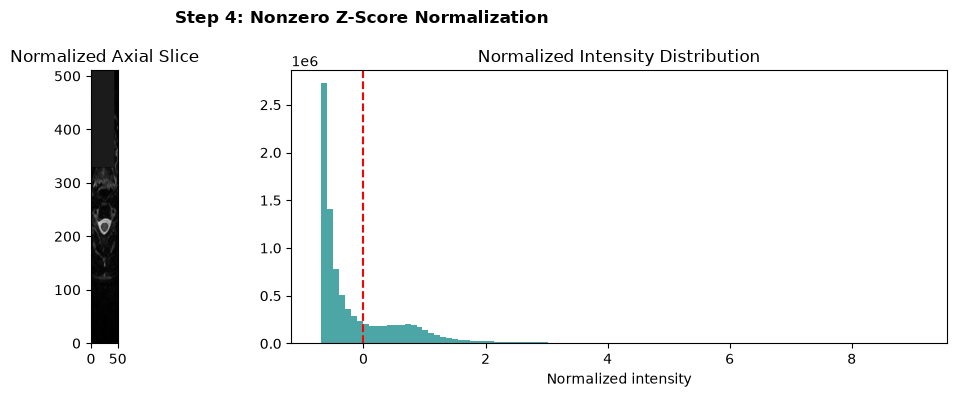

In [6]:
step4 = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True),
])
data_norm = step4(sample.copy())

img4 = data_norm['image']
nonzero = img4[img4 != 0]

print(f"After NormalizeIntensityd(nonzero=True):")
print(f"  Range:  [{img4.min():.2f}, {img4.max():.2f}]")
print(f"  Nonzero mean: {nonzero.mean():.4f} (should be ~0)")
print(f"  Nonzero std:  {nonzero.std():.4f} (should be ~1)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img4[0, :, :, img4.shape[3]//2].T, cmap='gray', origin='lower')
axes[0].set_title('Normalized Axial Slice')
axes[1].hist(nonzero.numpy().flatten(), bins=100, color='teal', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Normalized Intensity Distribution')
axes[1].set_xlabel('Normalized intensity')
plt.suptitle('Step 4: Nonzero Z-Score Normalization', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Random Patch Cropping

`RandCropByPosNegLabel` extracts patches centered on the label:
- **Patch size:** [48, 160, 160] — covers cord cross-section with context
- **pos:neg = 2:1** — 2/3 of patches contain cord, 1/3 are background
- **num_samples = 4** — 4 patches per volume per epoch

This is the KEY step for handling extreme class imbalance.

Patches generated: 4
Each patch shape:  [1, 48, 160, 160]
Expected:          [1, 48, 160, 160]


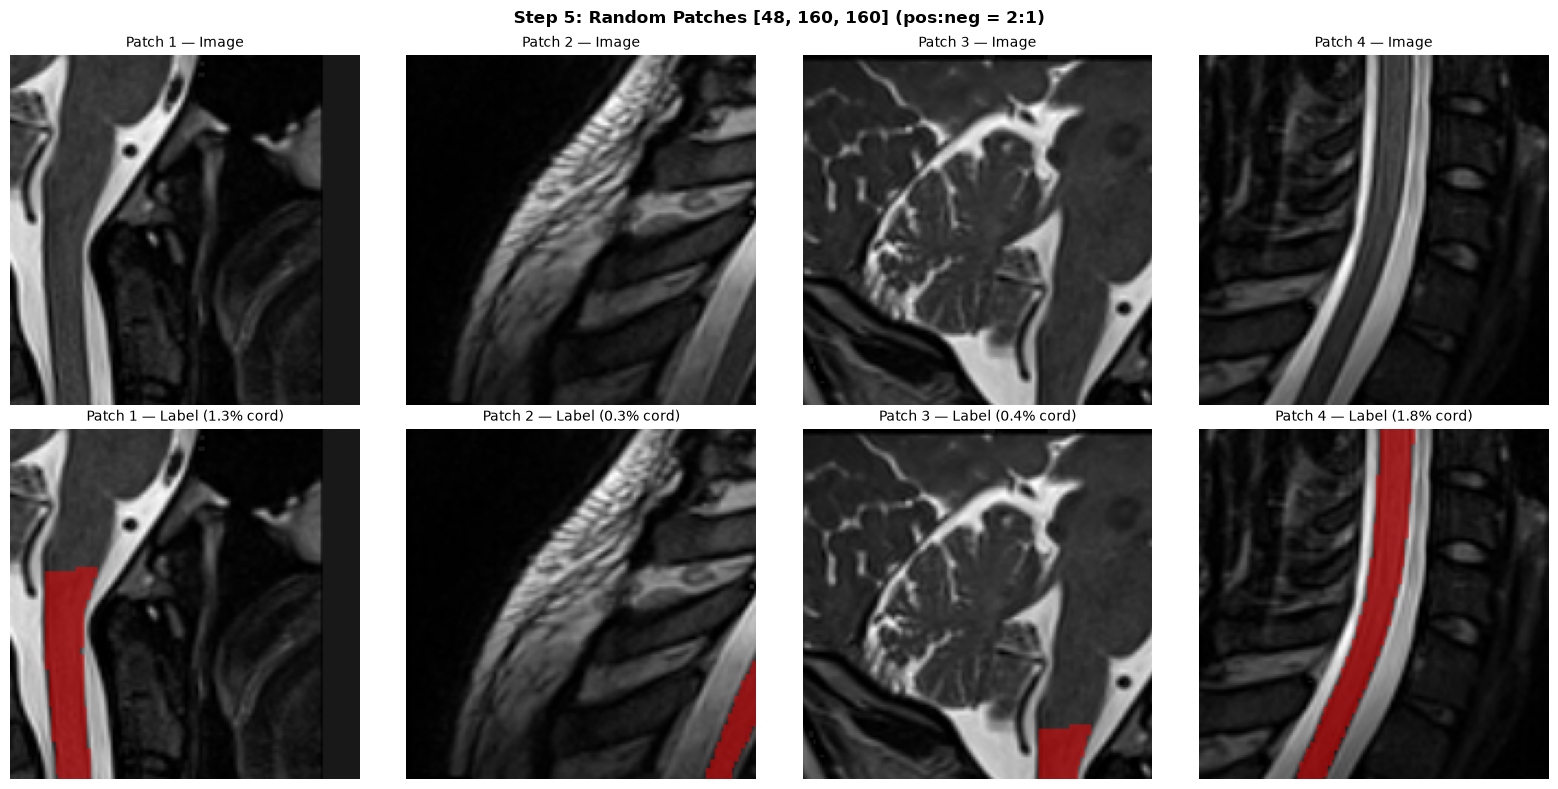

In [7]:
PATCH_SIZE = [48, 160, 160]
NUM_SAMPLES = 4

step5 = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH_SIZE,
        pos=2,  # 2/3 positive patches
        neg=1,  # 1/3 negative patches
        num_samples=NUM_SAMPLES,
    ),
])

patches = step5(sample.copy())

print(f"Patches generated: {len(patches)}")
print(f"Each patch shape:  {list(patches[0]['image'].shape)}")
print(f"Expected:          [1, {PATCH_SIZE[0]}, {PATCH_SIZE[1]}, {PATCH_SIZE[2]}]")

# Visualize all patches
fig, axes = plt.subplots(2, NUM_SAMPLES, figsize=(4 * NUM_SAMPLES, 8))

for i, patch in enumerate(patches):
    img_p = patch['image'][0]
    lbl_p = patch['label'][0]
    mid_z = img_p.shape[0] // 2
    
    # Image
    axes[0, i].imshow(img_p[mid_z, :, :].T, cmap='gray', origin='lower')
    axes[0, i].set_title(f'Patch {i+1} — Image', fontsize=10)
    axes[0, i].axis('off')
    
    # Label overlay
    axes[1, i].imshow(img_p[mid_z, :, :].T, cmap='gray', origin='lower')
    lbl_slice = lbl_p[mid_z, :, :].T
    if lbl_slice.sum() > 0:
        mask = np.ma.masked_where(lbl_slice == 0, lbl_slice)
        axes[1, i].imshow(mask, cmap='autumn', alpha=0.5, origin='lower')
    cord_pct = 100 * (lbl_p > 0).sum().item() / lbl_p.numel()
    axes[1, i].set_title(f'Patch {i+1} — Label ({cord_pct:.1f}% cord)', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle(f'Step 5: Random Patches {PATCH_SIZE} (pos:neg = 2:1)', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Augmentations

Applied ONLY during training to improve generalization:
- **RandFlip** (prob=0.5, axes 1,2): left-right / anterior-posterior flip
- **RandRotate90** (prob=0.3, axes 1,2): 90° rotation in axial plane
- **RandGaussianNoise** (prob=0.2, std=0.05): simulate scanner noise

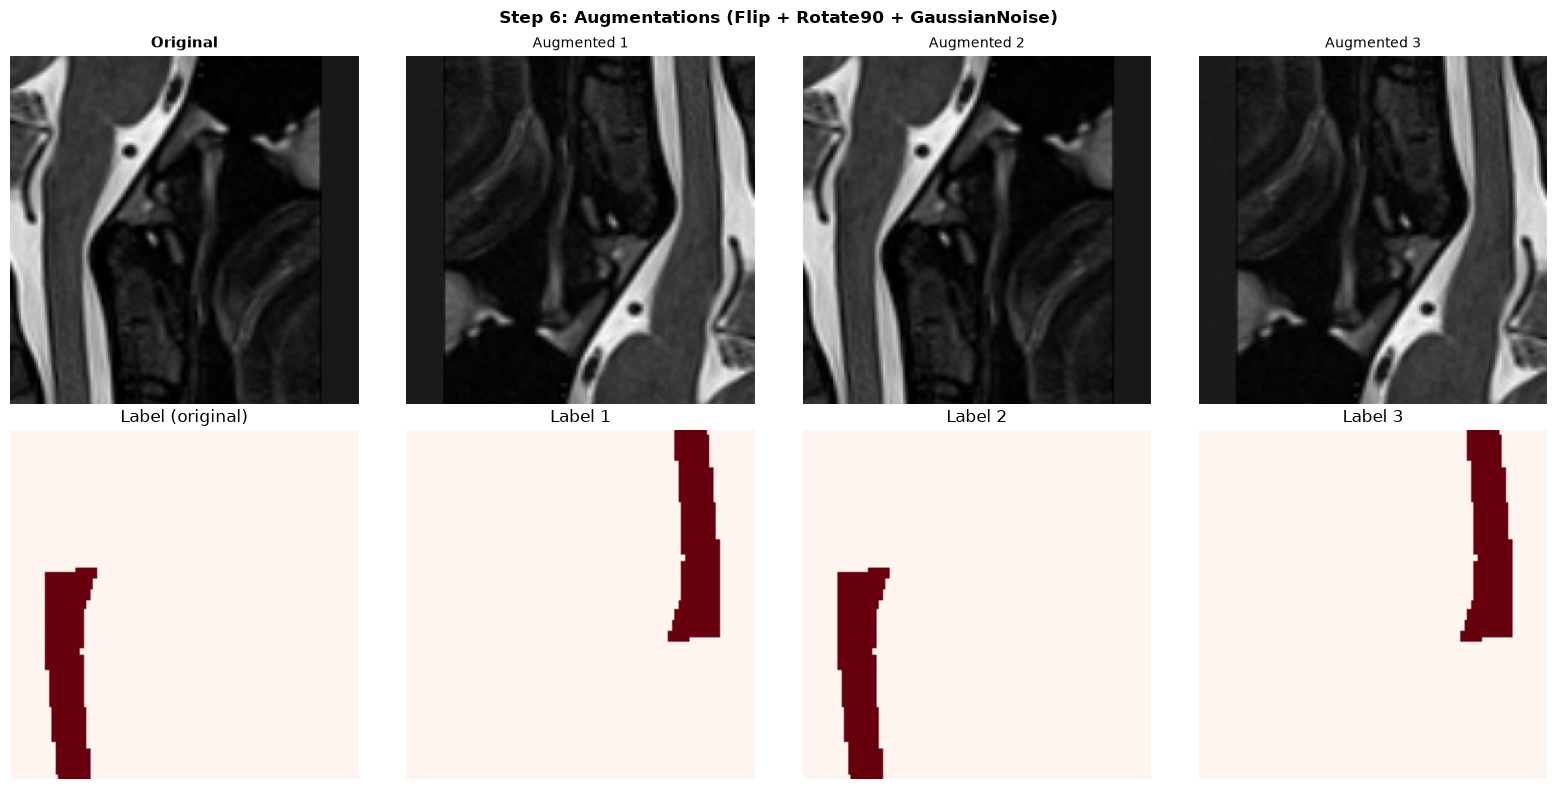

Notice: augmentations are applied identically to image AND label (geometric),
while noise is applied to image only.


In [8]:
# Apply augmentations to the same patch multiple times to see variation
augmentations = Compose([
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[1, 2]),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(1, 2)),
    RandGaussianNoised(keys="image", prob=0.8, std=0.05),  # high prob for demo
])

# Take the first patch and augment it 6 times
base_patch = patches[0]
augmented = [augmentations({k: v.clone() if isinstance(v, torch.Tensor) else v 
                            for k, v in base_patch.items()}) for _ in range(6)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
mid_z = PATCH_SIZE[0] // 2
axes[0, 0].imshow(base_patch['image'][0, mid_z, :, :].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].imshow(base_patch['label'][0, mid_z, :, :].T, cmap='Reds', origin='lower')
axes[1, 0].set_title('Label (original)')
axes[1, 0].axis('off')

# Augmented versions
for i, aug in enumerate(augmented[:3]):
    axes[0, i+1].imshow(aug['image'][0, mid_z, :, :].T, cmap='gray', origin='lower')
    axes[0, i+1].set_title(f'Augmented {i+1}', fontsize=10)
    axes[0, i+1].axis('off')
    axes[1, i+1].imshow(aug['label'][0, mid_z, :, :].T, cmap='Reds', origin='lower')
    axes[1, i+1].set_title(f'Label {i+1}')
    axes[1, i+1].axis('off')

plt.suptitle('Step 6: Augmentations (Flip + Rotate90 + GaussianNoise)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice: augmentations are applied identically to image AND label (geometric),")
print("while noise is applied to image only.")

## Full Pipeline Test

Let's run our actual `get_train_transforms` function end-to-end.

In [ ]:
from cns_segmentation.data.transforms import get_train_transforms, get_val_transforms

config = {
    "spacing": [1.0, 0.5, 0.5],
    "patch_size": [48, 160, 160],
    "num_samples": 4,
}

train_tfm = get_train_transforms(config)
val_tfm = get_val_transforms(config)

# Training output (list of patches)
train_result = train_tfm(sample.copy())
print(f"Training transform output: {len(train_result)} patches")
print(f"  Each: image={list(train_result[0]['image'].shape)}, label={list(train_result[0]['label'].shape)}")

# Validation output (full volume, no cropping)
val_result = val_tfm(sample.copy())
print(f"\nValidation transform output:")
print(f"  image={list(val_result['image'].shape)}, label={list(val_result['label'].shape)}")
print(f"  (Full volume — sliding window inference handles this)")

## Summary: Complete Preprocessing Pipeline

```
Raw NIfTI (variable shape/spacing/orientation)
    │
    ├── LoadImaged → numpy array + metadata
    ├── EnsureChannelFirstd → adds channel dim [1, X, Y, Z]
    ├── Orientationd("RAS") → standardized orientation
    ├── Spacingd([1.0, 0.5, 0.5]) → uniform voxel spacing
    ├── NormalizeIntensityd(nonzero=True) → z-score normalized
    │
    ├─[TRAIN]─ RandCropByPosNegLabel → [48, 160, 160] patches (×4)
    │           RandFlipd, RandRotate90d, RandGaussianNoised
    │
    └─[VAL]─── Full volume → SlidingWindowInferer at test time
```

**Next:** → Notebook 4 for model config and training